<a href="https://colab.research.google.com/github/vifirsanova/ML-2026-pt-2/blob/main/beginners/1_clustering/clustering_tutor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-04-12 12:28:29--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.02s   

2026-04-12 12:28:29 (4.00 MB/s) - ‘wineqr.csv’ saved [84143/84143]



1. Загрузка и предобработка

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('wineqr.csv')

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
X = df.drop(columns=['quality'])

In [ ]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. K-Means с выбором K (локоть + силуэт)

In [ ]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


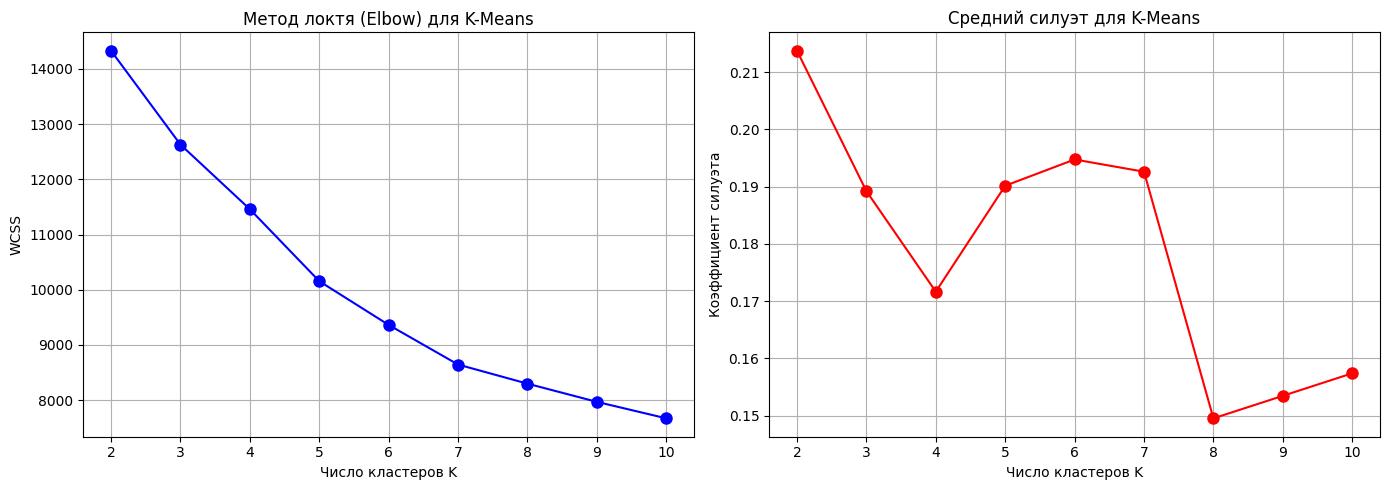

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

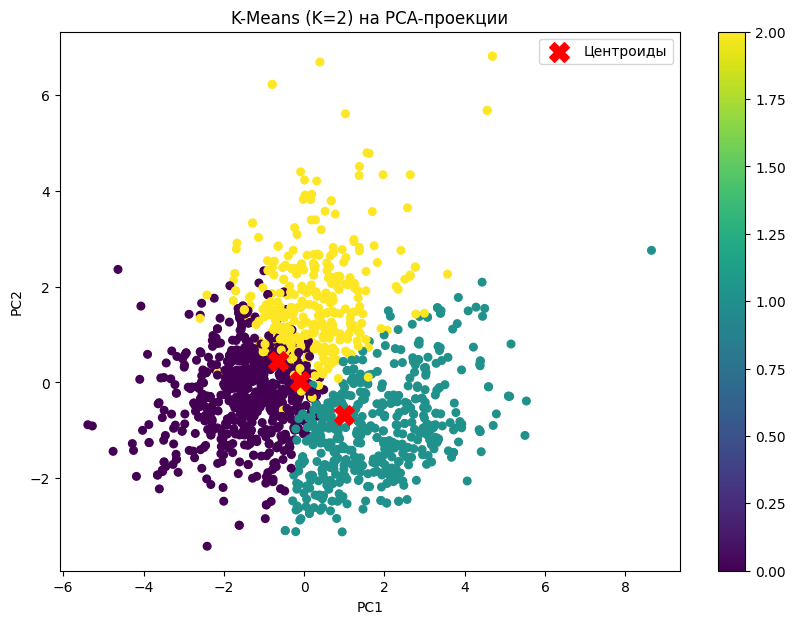

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()